In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Heat transfer : 

## Exercise 1: thermal inertia

<img src="figures/heat_ex5a.png" alt="ex5a" width="250"/>

We represent a building with a single thermal resistance $R$ (from the global heat transfer coefficient) and a single heat capacitance $C$. A heating power $\Phi$ is imposed on the indoor temperature. The evolution of the indoor temperature is thus driven by the differential equation:
\begin{equation}
C \frac{\partial T_i}{\partial t} = \frac{1}{R} \left(T_e-T_i\right) + \Phi
\end{equation}

### Question 1: winter conditions

We suppose that the building is initially at the same temperature $T_e$ as the outside. The heating is then turned on at a constant power $\Phi$.
1. Solve the equation above to show that the evolution of the indoor temperature is:
\begin{equation}
T_i = T_e + R \, \Phi \left(1-\mathrm{exp}\left(-\frac{t}{RC}\right)\right)
\end{equation}
2. Draw the evolution of $T_i$. How does this graph change with different values of $R$ and $C$?

### Solution

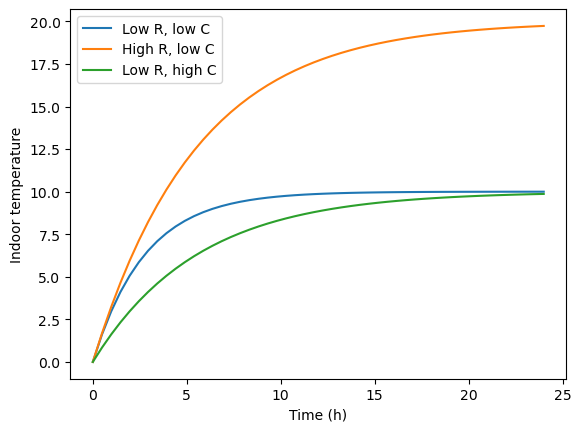

In [2]:
# Suppose an outdoor temperature 0°C and heating power 1000 W
Te = 0
Phi = 1000
t = np.linspace(0, 86400) # 24 heures

# L'équation de la température intérieure
def T(R, C):
  return Te + R*Phi*(1-np.exp(-t/R/C))

# Tracer un graphe
plt.figure()
plt.plot(t/3600, T(0.01, 1e6), label="Low R, low C")
plt.plot(t/3600, T(0.02, 1e6), label="High R, low C")
plt.plot(t/3600, T(0.01, 2e6), label="Low R, high C")
plt.xlabel("Time (h)")
plt.ylabel("Indoor temperature")
plt.legend()

### Question 2: summer conditions

<img src="figures/heat_ex5b.png" alt="ex5b" width="250"/>

We now suppose that the outdoor temperature is a sine wave (see Fig. \ref{fig:inertia2}). There is no heating: $\Phi=0$. The outdoor temperature varies between 10°C and 30°C, with a period of 24h.
\begin{align}
T_e & = 20 + 10 \, \mathrm{sin}(\omega \, t) \\
\omega & = \frac{2 \pi}{24 \times 3600}
\end{align}
We can show that the complex impedance of the building is:
\begin{equation}
Z(j\omega) = \frac{T_i}{T_e} = \frac{1}{1+jRC\omega}
\end{equation}
Draw the evolution of $T_i$. How does this graph change with different values of $R$ and $C$?

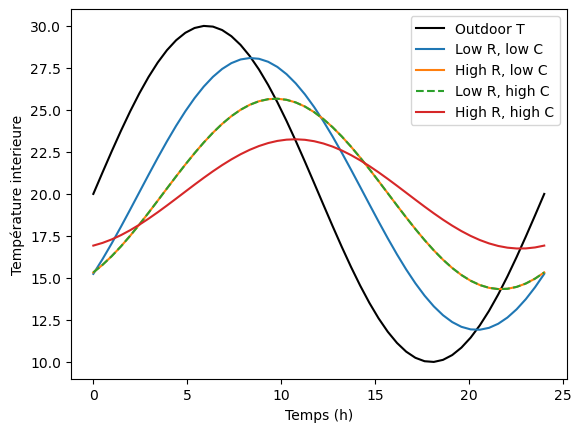

In [3]:
t = np.linspace(0, 86400) # 24 heures
omega = 2*np.pi / 24 / 3600
Te = 20 + 10 * np.sin(omega*t)

# L'équation de la température intérieure
def T(R, C):
  A = 10 / np.sqrt(1+(R*C*omega)**2)
  psi = -np.arctan(R*C*omega)
  return 20 + A * np.sin(omega*t + psi)

# Tracer un graphe
plt.figure()
plt.plot(t/3600, Te, '-k', label="Outdoor T")
plt.plot(t/3600, T(0.01, 1e6), label="Low R, low C")
plt.plot(t/3600, T(0.02, 1e6), label="High R, low C")
plt.plot(t/3600, T(0.01, 2e6), label="Low R, high C", linestyle='--')
plt.plot(t/3600, T(0.02, 2e6), label="High R, high C")
plt.xlabel("Temps (h)")
plt.ylabel("Température interieure")
plt.legend()


## Exercise 2: transient simulation

<img src="figures/heat_ex5a.png" alt="ex5a" width="250"/>

We represent a building with a single thermal resistance $R$ (from the global heat transfer coefficient) and a single heat capacitance $C$. The solar irradiance $I_{sol}$ contributes to indoor heating through a coefficient $\alpha$. A heating power $\Phi$ is imposed on the indoor temperature. The evolution of the indoor temperature is thus driven by the differential equation:
\begin{equation}
C \frac{\partial T_i}{\partial t} = \frac{1}{R} \left(T_e-T_i\right) + \Phi + \alpha I_{sol}
\end{equation}

This balance equation can be discretised with an implicit scheme, in order to formulate the indoor temperature as function of the previous temperature and of the environment variables:

$$ C \frac{T_i^{t+1}-T_i^t}{\Delta t} = \frac{1}{R} \left(T_e^{t+1}-T_i^{t+1}\right) + \Phi^{t+1} + \alpha I_{sol}^{t+1}$$

$$ T_i^{t+1} = \frac{1}{C/\Delta t+1/R} \left( \frac{C}{\Delta t} T_i^t + \frac{1}{R} T_e^{t+1} + \Phi^{t+1} + \alpha I_{sol}^{t+1} \right) $$

### Part 1: example

We want to show the evolution of indoor temperature if there is no heating. We assume the following properties of the building:

* $C=10^7$ J/K
* $R = 8 \times 10^{-3}$ K/W
* $\alpha=2$ m$^2$

Weather data are in the file `workshop1_data.xlsx`. The following block loads this data and plots the outdoor temperature and solar irradiance

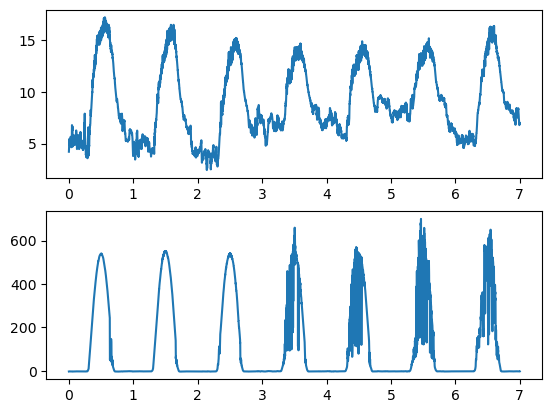

In [4]:

df = pd.read_excel('workshop1_data.xlsx')

time = df['Time (s)']
te = df['Te (C)']
isol = df['Isol (W/m2)']

fig, axes = plt.subplots(nrows=2, ncols=1)
axes[0].plot(time/24/3600, te)
axes[1].plot(time/24/3600, isol)
plt.show()

The following block calculates the indoor temperature, one time point after the other. We suppose that the initial value is equal to the outdoor temperature.

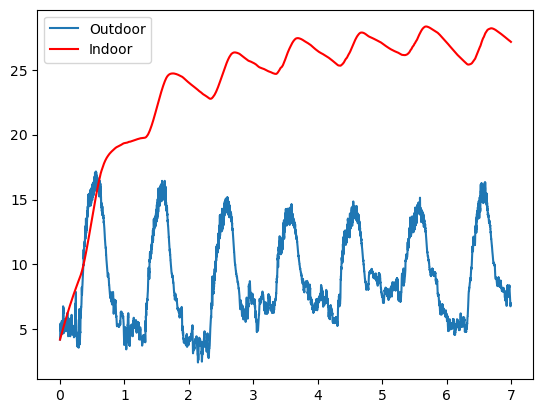

In [5]:
# initialization
ti = np.zeros(len(df))
ti[0] = te[0]

# Building properties
C = 1e7
R = 8e-3
alpha = 2
Phi = 2000

# Calculation of the indoor temperature
for t in range(1, len(df)):
    dt = time[t] - time[t-1]
    ti[t] = 1/(C/dt + 1/R) * ( C/dt*ti[t-1] + 1/R*te[t] + Phi + alpha*isol[t])

fig, axes = plt.subplots(nrows=1, ncols=1)
axes.plot(time/24/3600, te, label='Outdoor')
axes.plot(time/24/3600, ti, color='red', label='Indoor')
axes.legend()
plt.show()